# M2 EDA — 用眼睛認識 WM-811K

M1 用**數字**認識資料，M2 用**眼睛**。目標是建立 *domain sense*：
親眼看過每類瑕疵後，才會懂後面所有建模決策為什麼合理
（例如為什麼旋轉增強有效、為什麼 random/scratch 難分）。

**本 notebook 會回答的問題：**
1. 類別不平衡長什麼樣？（none 85% 的視覺衝擊）
2. 0/1/2 的**語意**是什麼？（M1 遺留 — 畫出來驗證）
3. 8 種瑕疵各長什麼樣？（圖鑑）
4. waferMap 尺寸分佈 → 32×32 定案素材
5. dieSize 極端值檢查（M1 發現 min=3、max=48,100）
6. 同 lot 的 wafer 有多像？（洩漏問題眼見為憑）

> 執行方式：Cell → Run All（載入約 2.5–3 分鐘）。圖會存到 `artifacts/eda/`。
> **每張圖下面都有「觀察問題」，先自己回答再繼續** — 這是你自己的探索。

In [1]:
# ── 全域設定 ──
%matplotlib inline
import sys
from pathlib import Path

# kernel 的 cwd 是 notebooks/（notebook 所在目錄），需向上找到專案根的 src/
def _find_src():
    p = Path.cwd()
    for _ in range(4):
        if (p / "src" / "wm811k").exists():
            return p / "src"
        p = p.parent
    return None

_src = _find_src()
if _src:
    sys.path.insert(0, str(_src))
else:
    raise RuntimeError("找不到 src/wm811k — 請確認在專案目錄內執行")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from wm811k import config
from wm811k.loader import load_lswmd, unwrap_scalar

# 圖內文字用英文：容器沒有中文字型，中文會變方塊
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")
ART = Path("artifacts/eda")
ART.mkdir(parents=True, exist_ok=True)
print("setup OK")

setup OK


In [2]:
# ── 載入 LSWMD.pkl（約 2.5–3 分鐘；雙重古董 pickle 相容層在 loader.py）──
df = load_lswmd()
print("loaded:", len(df), "rows")

# 標準化（M1 發現：每格巢狀結構、Title Case、空容器=無標籤）
df["failure"] = df["failureType"].map(unwrap_scalar).str.lower()
df["split"]   = df["trianTestLabel"].map(unwrap_scalar)   # 注意 MIR 拼錯的欄位名
df["lot"]     = df["lotName"].map(unwrap_scalar)

lab = df[df["failure"] != ""].copy()    # 有標籤子集（172,950）
print("labelled:", len(lab))

loaded: 811457 rows
labelled: 172950


## Part A — 類別不平衡（用眼睛感受 85%）

none 佔有標籤資料 85%。畫成長條圖時，**數量級差 1000 倍**（147k vs 149），
若用線性刻度，Near-full 那一根會貼在地上看不到 → 改用 **log 刻度**。
這就是「視覺化要配合資料特性」的第一課。

**觀察問題：** 最少的 Near-full 只有 149 張 — 如果我們直接訓練，模型會怎麼對待它？

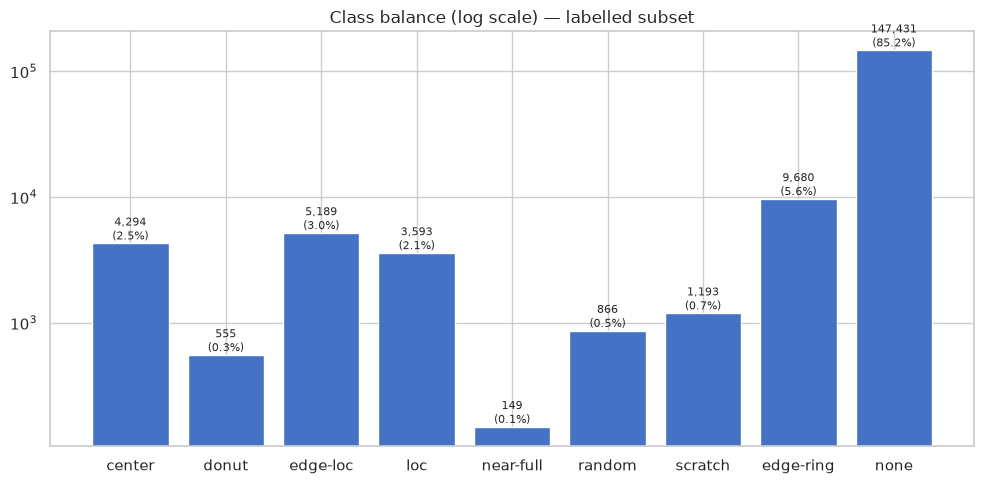

In [3]:
# 類別計數，照 config 順序排列
order = [c for c in config.FAILURE_TYPES if c in set(lab["failure"])]
counts = lab["failure"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color="#4472C4")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / len(lab):.1%})",
            ha="center", va="bottom", fontsize=8)
ax.set_yscale("log")
ax.set_title("Class balance (log scale) — labelled subset")
plt.tight_layout()
plt.savefig(ART / "class_balance.png", dpi=150)
plt.show()

## Part B — 0/1/2 語意視覺驗證（M1 遺留問題）

M1 只驗證了數值集合是 {0,1,2}，但**哪個數字代表什麼**要畫出來才知道。

先定義一套 colormap（這是**猜測**，看完圖回答問題）：
- `0` = 淺灰、`1` = 黑、`2` = 藍

**觀察問題：**
1. 藍色(2) 的分布是否形成**晶圓的圓形/外框**？（若是 → 2 = 無 die 區域，晶圓是圓的、圖是方的）
2. 黑色(1) 是否都出現在藍色「圓內」？
3. none 類的圖，黑色(1) 是稀疏隨機、還是幾乎沒有？

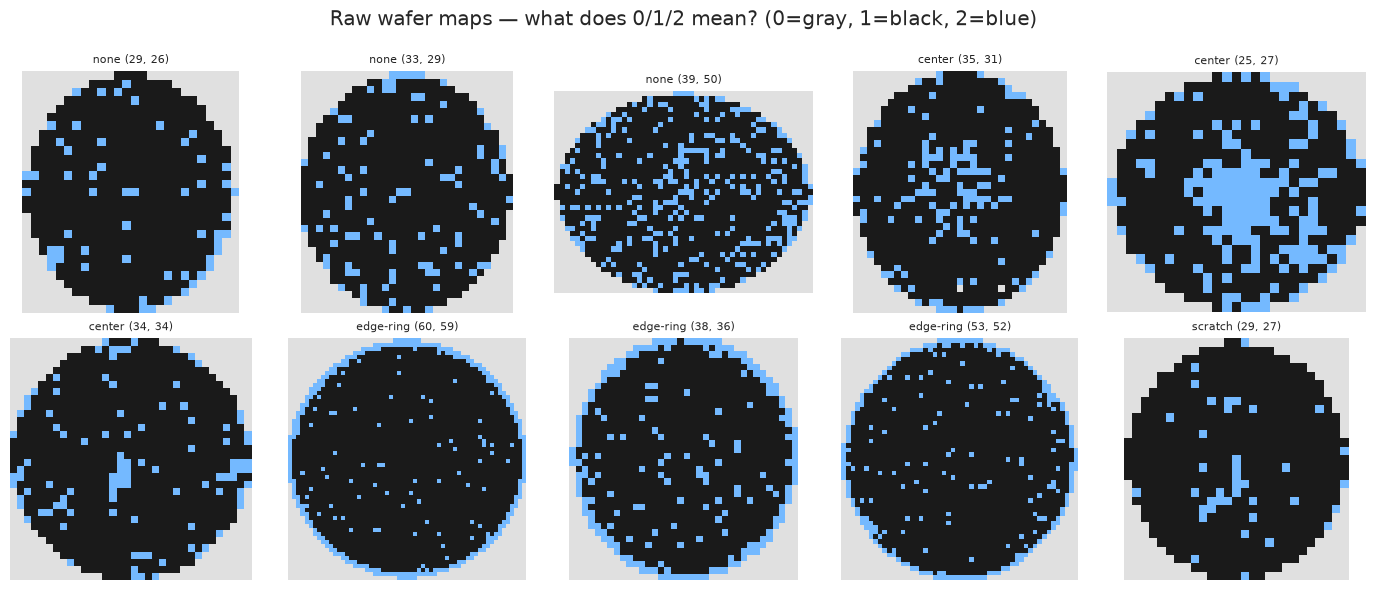

In [4]:
# 抽不同類別的原始 waferMap 來看 0/1/2 的幾何意義
cmap = mcolors.ListedColormap(["#e0e0e0", "#1a1a1a", "#74b9ff"])  # 0灰 1黑 2藍

sample_idx = []
for f in ["none", "center", "edge-ring", "scratch", "loc"]:
    sample_idx += list(lab[lab["failure"] == f].sample(3, random_state=42).index)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, idx in zip(axes.ravel(), sample_idx):
    arr = df.loc[idx, "waferMap"]
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"{df.loc[idx, 'failure']} {arr.shape}", fontsize=8)
    ax.axis("off")
plt.suptitle("Raw wafer maps — what does 0/1/2 mean? (0=gray, 1=black, 2=blue)")
plt.tight_layout()
plt.savefig(ART / "value_semantics.png", dpi=150)
plt.show()

## Part C — 每類圖鑑（8 種瑕疵的長相）

把整張圖畫出來時，大片的 pass die（灰）會蓋過少數 fail die（黑）。
所以圖鑑改用 **mask 畫法：只把 fail(1) 畫黑**，瑕疵圖案才清晰可見。
（這也預告了模型要學的是什麼：**fail die 的空間圖案**。）

**觀察問題：** 先蓋住類別名猜一遍，再對答案 — 你認得出幾種？
特別注意 none 那一列（應該全白 = 沒有 fail die）。

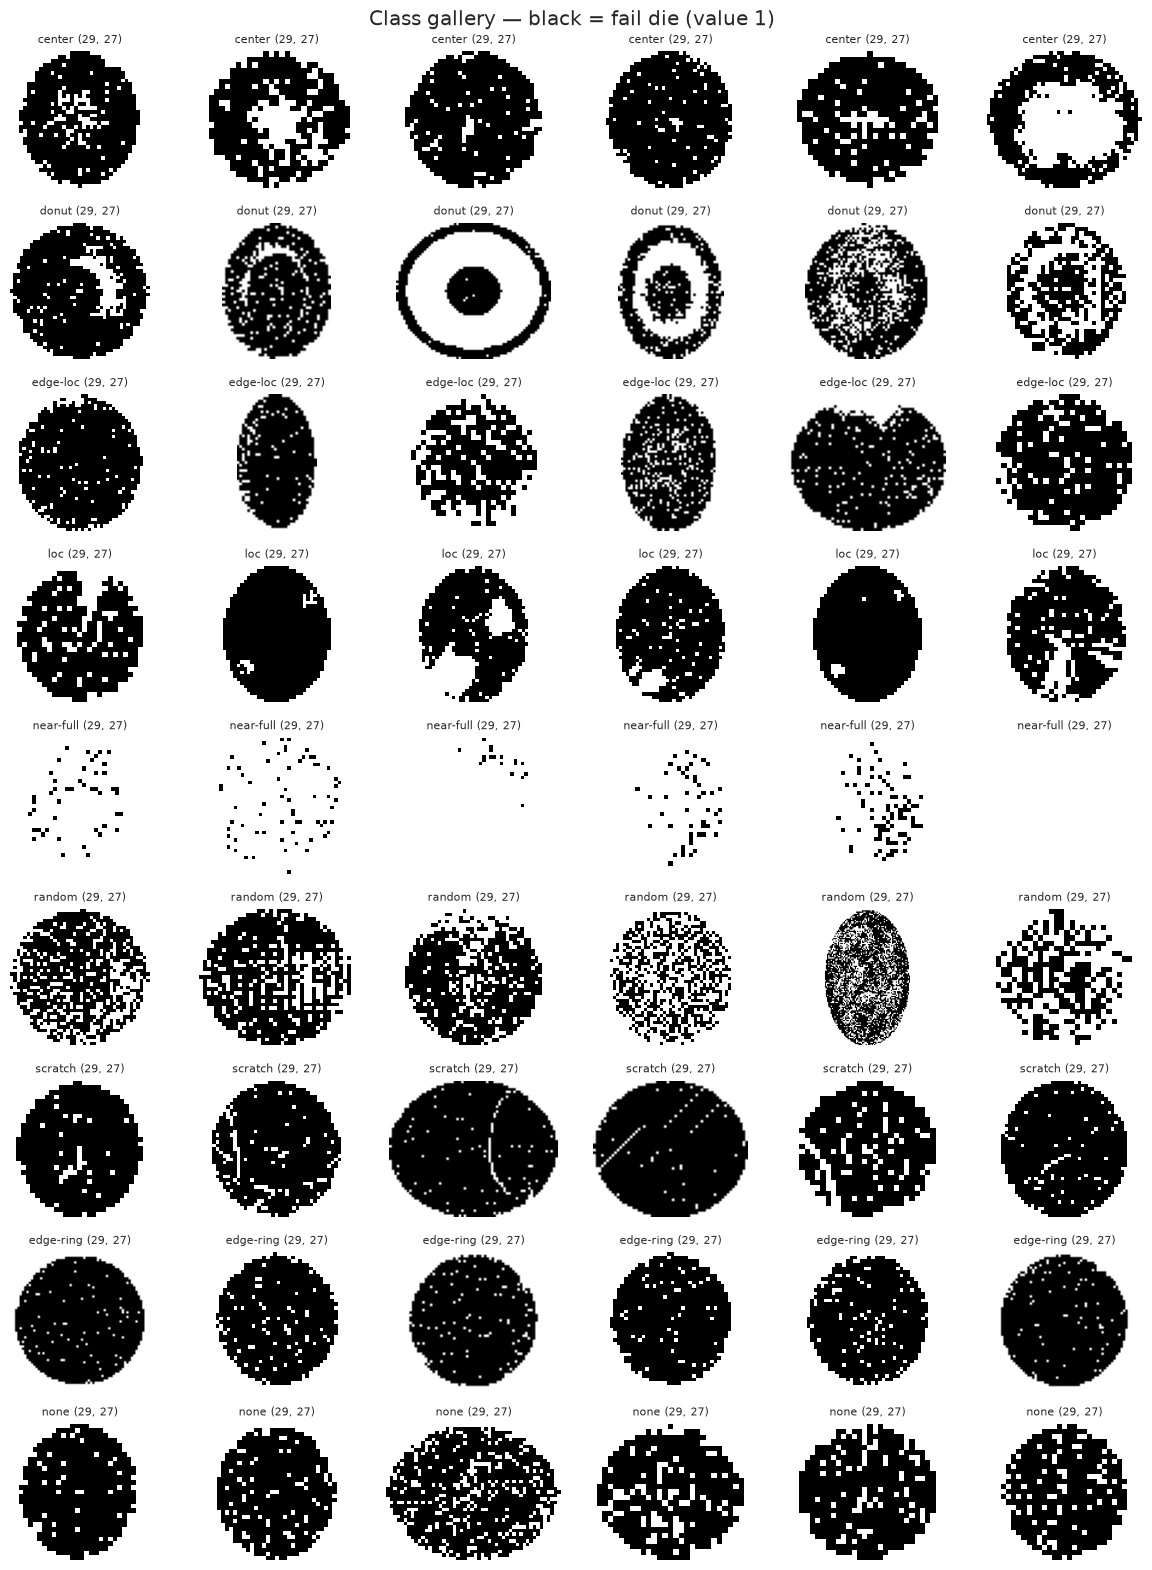

In [5]:
# 每類抽 6 張；mask 畫法：arr == 1 → 黑
fig, axes = plt.subplots(9, 6, figsize=(12, 16))
for r, f in enumerate(config.FAILURE_TYPES):
    sub = lab[lab["failure"] == f].sample(6, random_state=42)
    for c, idx in enumerate(sub.index):
        axes[r, c].imshow(df.loc[idx, "waferMap"] == 1, cmap="gray_r")
        axes[r, c].axis("off")
        axes[r, c].set_title(f"{df.loc[idx, 'failure']} {arr.shape}", fontsize=8)
    axes[r, 0].set_ylabel(f, fontsize=10, rotation=0, labelpad=32)
plt.suptitle("Class gallery — black = fail die (value 1)")
plt.tight_layout()
plt.savefig(ART / "class_gallery.png", dpi=150)
plt.show()

## Part D — 尺寸分佈（32×32 定案素材）

M1 發現尺寸範圍很大：高 6–300、寬 3–205。看完整分佈才能決定
「統一尺寸」策略。811k 張全畫太慢，**抽 5 萬張**就足以看趨勢。

**觀察問題：**
1. 尺寸是「集中在少數幾種」還是「連續分佈」？
2. 有沒有發現尺寸與 dieSize 的關係？（die 大 → grid 小？）
3. 若直接 resize 到 32×32：300 寬的大圖會怎樣？（細節壓扁）→ M2 定案討論素材

median h, w : 36.0 34.0
max    h, w : 300 205
rows <= 64  : 87.1% | cols <= 64: 85.5%


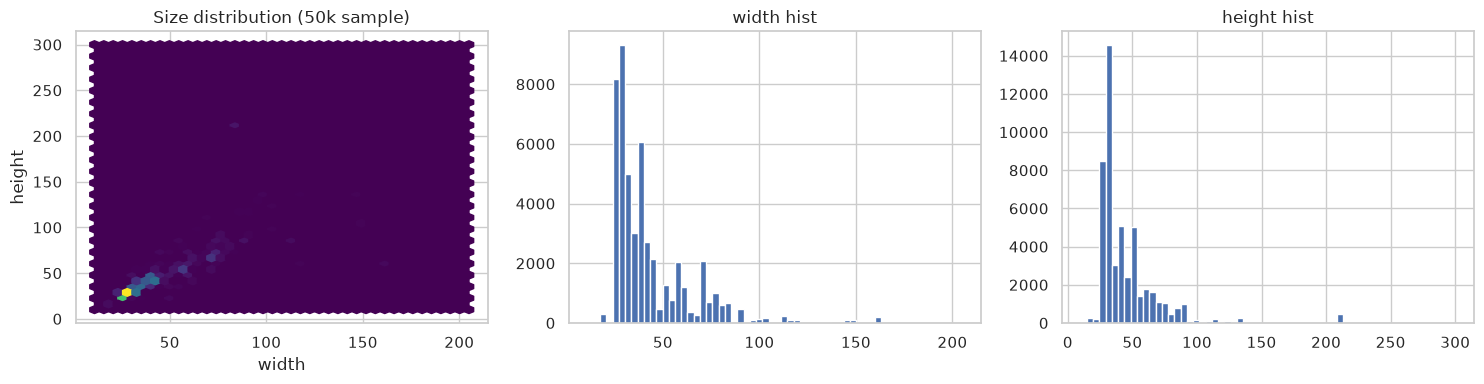

In [6]:
# 抽 5 萬張的寬高（讀 shape 是 metadata，很快）
rows_list = [a.shape for a in df["waferMap"].sample(50_000, random_state=42)]
shapes = pd.DataFrame(rows_list, columns=["h", "w"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hexbin(shapes["w"], shapes["h"], gridsize=40, cmap="viridis")
axes[0].set_xlabel("width"); axes[0].set_ylabel("height")
axes[0].set_title("Size distribution (50k sample)")
axes[1].hist(shapes["w"], bins=60); axes[1].set_title("width hist")
axes[2].hist(shapes["h"], bins=60); axes[2].set_title("height hist")
print("median h, w :", shapes["h"].median(), shapes["w"].median())
print("max    h, w :", shapes["h"].max(), shapes["w"].max())
print("rows <= 64  :", f"{(shapes['h'] <= 64).mean():.1%}",
      "| cols <= 64:", f"{(shapes['w'] <= 64).mean():.1%}")
plt.tight_layout()
plt.savefig(ART / "size_dist.png", dpi=150)
plt.show()

## Part E — dieSize（M1 發現 min=3、max=48,100）

dieSize 是「單顆 die 的實體邊長」。同一個 lot 用同一種 die，
所以 dieSize 的離散值 ≈ 不同產品線。M1 看到的極端值（3、48,100）
是資料錯誤、還是真實產品？畫出來 + 抽樣檢查。

**觀察問題：** dieSize 與 wafer map 的 grid 大小有關係嗎？
（實體 wafer 大小固定 → die 越大，一張 wafer 能切的 die 越少）

dieSize top10:
dieSize
710.0     66961
515.0     45725
712.0     42572
1513.0    39322
776.0     29513
533.0     29391
846.0     23886
741.0     20373
516.0     18082
2393.0    14787
Name: count, dtype: int64

極端值列數: 220
        dieSize       lot  waferIndex
9043    21338.0   lot1695         2.0
9044    21338.0   lot1695         3.0
9045    21338.0   lot1695         4.0
9046    21338.0   lot1695         5.0
243628  23216.0  lot15205        16.0
243629  23216.0  lot15205        17.0
243630  23216.0  lot15206        18.0
243631  23216.0  lot15206        19.0
243632  23216.0  lot15206        20.0
243633  23216.0  lot15206        21.0



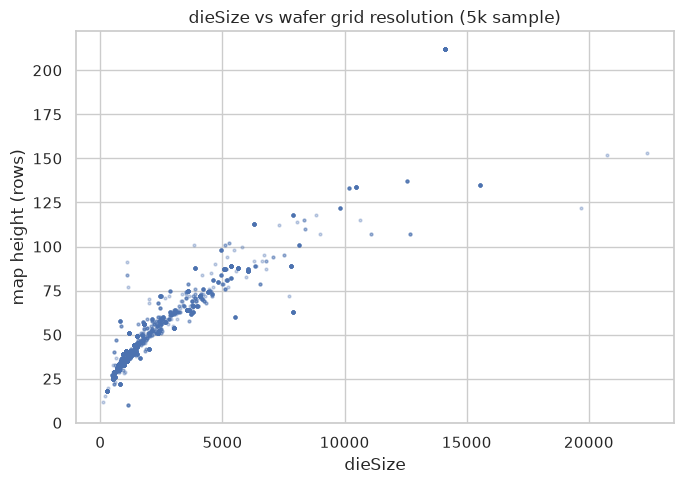

In [7]:
print("dieSize top10:")
print(df["dieSize"].value_counts().head(10))
print()

extreme = df[(df["dieSize"] < 10) | (df["dieSize"] > 20000)]
print("極端值列數:", len(extreme))
print(extreme[["dieSize", "lot", "waferIndex"]].head(10))
print()

# dieSize vs grid 大小（抽 5000 張）— 看是否有反比關係
sub = df.sample(5000, random_state=42)
hs = np.array([a.shape[0] for a in sub["waferMap"]])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sub["dieSize"], hs, s=4, alpha=0.3)
ax.set_xlabel("dieSize"); ax.set_ylabel("map height (rows)")
ax.set_title("dieSize vs wafer grid resolution (5k sample)")
plt.tight_layout()
plt.savefig(ART / "diesize.png", dpi=150)
plt.show()

## Part F — lot 檢查（洩漏問題眼見為憑）

同一 lot = 同一片晶圓的「鄰居」切片（同一批製程、同一光罩）。
M6 要做 lot 洩漏對照，先在這裡**用眼睛確認**同 lot 的 wafer 有多像。

**觀察問題：** 抽出來的那個 lot，8 張圖是不是長得都很像？
如果是 — 隨機切分時，同 lot 的圖同時出現在 train 和 test，
模型是不是「作弊」了？（記住這個感覺，M6 我們量化它）

count    46293.000000
mean        17.528719
std          8.964477
min          1.000000
25%         10.000000
50%         24.000000
75%         25.000000
max         25.000000
Name: waferIndex, dtype: float64


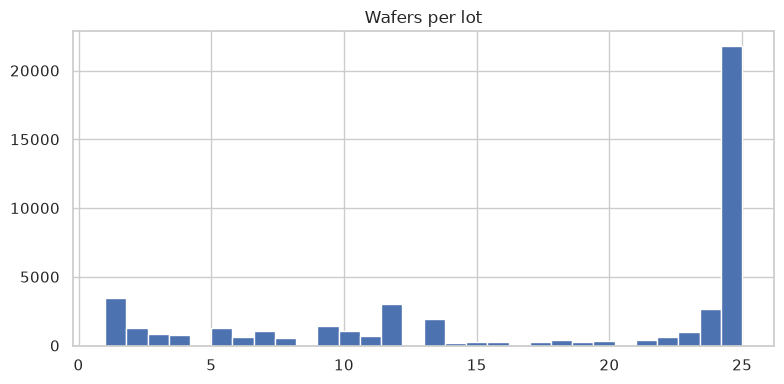

In [8]:
# 每 lot 有幾片 wafer
per_lot = df.groupby("lot")["waferIndex"].count()
print(per_lot.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_lot, bins=30)
ax.set_title("Wafers per lot")
plt.tight_layout()
plt.savefig(ART / "lot_size.png", dpi=150)
plt.show()

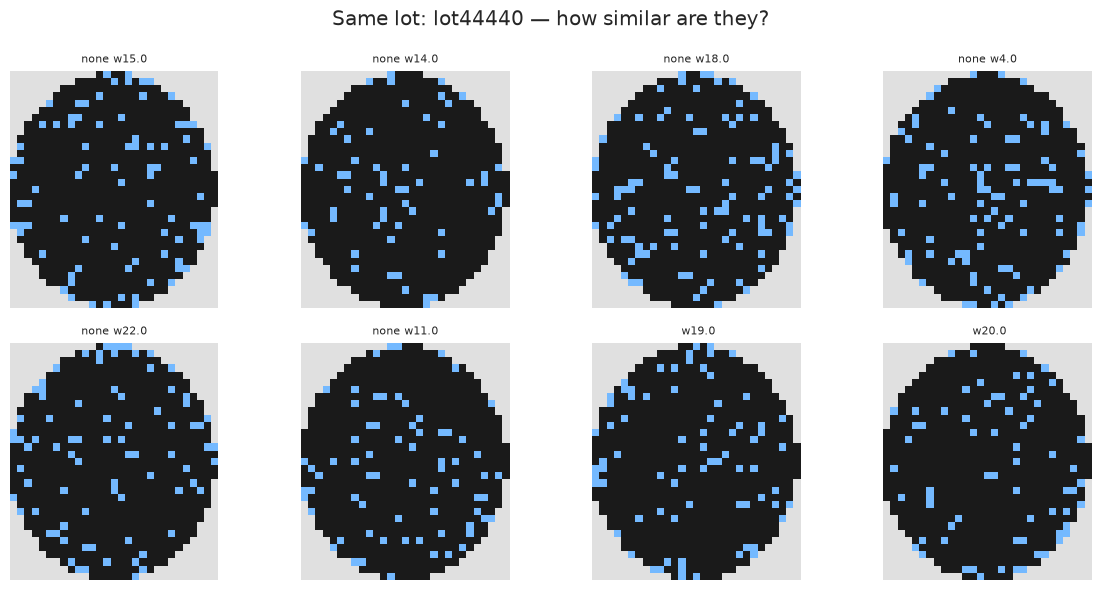

In [9]:
# 抽 1 個含瑕疵的 lot，看同 lot 相似性
lot_cand = lab.groupby("lot")["failure"].nunique()
lot_cand = lot_cand[lot_cand >= 2]          # 至少含 2 種標籤的 lot
chosen = lot_cand.sample(1, random_state=42).index[0]
sub = df[df["lot"] == chosen].sample(8, random_state=1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), sub.index):
    ax.imshow(df.loc[idx, "waferMap"], cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"{df.loc[idx, 'failure']} w{df.loc[idx, 'waferIndex']}", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Same lot: {chosen} — how similar are they?")
plt.tight_layout()
plt.savefig(ART / "lot_sample.png", dpi=150)
plt.show()

## Part G — M2 定案討論（看完圖回答，我們一起討論後寫進 notes.md）

1. **0/1/2 語意**：你看 Part B 的結論是什麼？（哪個數字 = pass / fail / 無 die）
2. **尺寸策略**：32×32 直接 resize？還是「先裁最大內接方再縮放」？（Part D 的極端大圖）
3. **9 類 vs 8 類**：none 的圖真的乾淨嗎？保留 none 的好處？（Part C 圖鑑）
4. **切分**：內建 split 的 Test(68.6%) > Training(31.4%)，要用它還是自行 stratified？（Part A 資訊）
5. 看完圖鑑，你覺得哪兩類**最容易混淆**？（預測一下模型的困難點）

In [10]:
# 定案輔助數字（看完圖回來填答案）
print("none 佔有標籤比例:", f"{(lab['failure'] == 'none').mean():.1%}")
print("有標籤內建切分   :", lab["split"].value_counts().to_dict())
print("waferMap 尺寸(全):",
      f"h {min(a.shape[0] for a in df['waferMap'])}–{max(a.shape[0] for a in df['waferMap'])},",
      f"w {min(a.shape[1] for a in df['waferMap'])}–{max(a.shape[1] for a in df['waferMap'])}")
print("\n（計算全量 min/max 需掃 811k 張，約 10–20 秒）")

none 佔有標籤比例: 85.2%
有標籤內建切分   : {'Test': 118595, 'Training': 54355}
waferMap 尺寸(全): h 6–300, w 3–205

（計算全量 min/max 需掃 811k 張，約 10–20 秒）


In [11]:
# 0/1/2 語意自證：正常片(none) vs 缺陷片(center) 的數值分佈
for cls in ["none", "center"]:
    sub = lab[lab["failure"] == cls].head(20)
    vals = np.concatenate([df.loc[i, "waferMap"].ravel() for i in sub.index])
    u, c = np.unique(vals, return_counts=True)
    print(cls, {int(k): round(v, 1) for k, v in zip(u, c / len(vals) * 100)})


none {0: np.float64(22.1), 1: np.float64(74.4), 2: np.float64(3.5)}
center {0: np.float64(20.5), 1: np.float64(60.8), 2: np.float64(18.6)}


In [12]:
# 驗證假設：random 的 fail die 密度顯著高於 none？
for cls in ["none", "random"]:
    sub = lab[lab["failure"] == cls]
    dens = []
    for i in sub.index[:300]:
        m = df.loc[i, "waferMap"]
        dens.append((m == 2).mean() * 100)  # fail die 佔整張圖 %
    dens = np.array(dens)
    print(f"{cls}: median {np.median(dens):.1f}%  "
          f"p25 {np.percentile(dens, 25):.1f}%  p75 {np.percentile(dens, 75):.1f}%")


none: median 10.7%  p25 5.8%  p75 13.5%
random: median 38.7%  p25 35.8%  p75 43.8%


In [13]:
rng = np.random.default_rng(42)
for cls in ["none", "random"]:
    sub = lab[lab["failure"] == cls]
    idxs = sub.index if cls == "random" else rng.choice(sub.index, 3000, replace=False)
    dens = np.array([(df.loc[i, "waferMap"] == 2).mean() * 100 for i in idxs])
    print(f"{cls}: n={len(dens)}  median {np.median(dens):.1f}%  "
          f"p25 {np.percentile(dens,25):.1f}%  p75 {np.percentile(dens,75):.1f}%  "
          f"min {dens.min():.1f}%  max {dens.max():.1f}%")


none: n=3000  median 7.6%  p25 5.0%  p75 10.7%  min 0.4%  max 27.6%
random: n=866  median 37.4%  p25 32.4%  p75 42.9%  min 12.4%  max 59.8%
